# Feature Standardization (IT25103309 - Madhusara J. P. M.)

## 1. Explanation of the Technique
Feature Standardization (Z-score normalization) is a preprocessing technique that rescales the features of a dataset so that they have the properties of a standard normal distribution with a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1.

## 2. Justification for the Letter Recognition Dataset
The Letter Recognition dataset contains 16 numerical features (e.g., x-box, y-box, width, high) that represent pixel counts and statistical moments. Although they are scaled to integer values from 0 to 15, they have different centers and spreads. Standardization is crucial here because distance-based machine learning algorithms (like KNN or SVM) or PCA give equal weight to all features only when they are on a comparable scale.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the dataset
columns = ['lettr', 'x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar',
           'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']

df = pd.read_csv('data/raw/letter-recognition.data', names=columns)

# Display the first few rows
df.head()

,lettr,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [2]:
# 1. Separating features (X) and target label (y)
X = df.drop('lettr', axis=1) # All columns except the letter
y = df['lettr'] # Only the letter column

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit and transform the features (Apply Standardization)
X_scaled = scaler.fit_transform(X)

# 4. Convert the scaled features back to a DataFrame for better visibility
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the standardized data
df_scaled.head()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,-1.057698,0.291877,-1.053277,-0.164704,-1.144013,0.544130,2.365097,-1.714360,0.344994,-0.917071,1.347774,0.034125,-1.305948,-0.219082,-1.438153,0.122911
1,0.510385,1.502358,-1.053277,0.719730,-0.687476,1.531305,-1.075326,0.137561,-0.495072,1.895968,-1.312807,0.514764,-0.448492,-0.219082,0.120081,1.359441
2,-0.012309,1.199738,0.435910,1.161947,1.138672,1.531305,-0.645273,-0.973591,0.344994,0.690380,-1.312807,-0.446513,-0.019764,-0.865626,-0.269477,0.741176
3,1.555774,1.199738,0.435910,0.277513,-0.230939,-0.936631,0.644886,-0.232823,0.344994,-1.720796,-0.932724,0.995402,1.266419,1.074008,-0.659036,0.122911
4,-1.057698,-1.826464,-1.053277,-1.933571,-1.144013,0.544130,-0.645273,0.507945,0.344994,-0.917071,-0.552641,0.514764,-0.877220,-0.865626,0.509640,1.359441


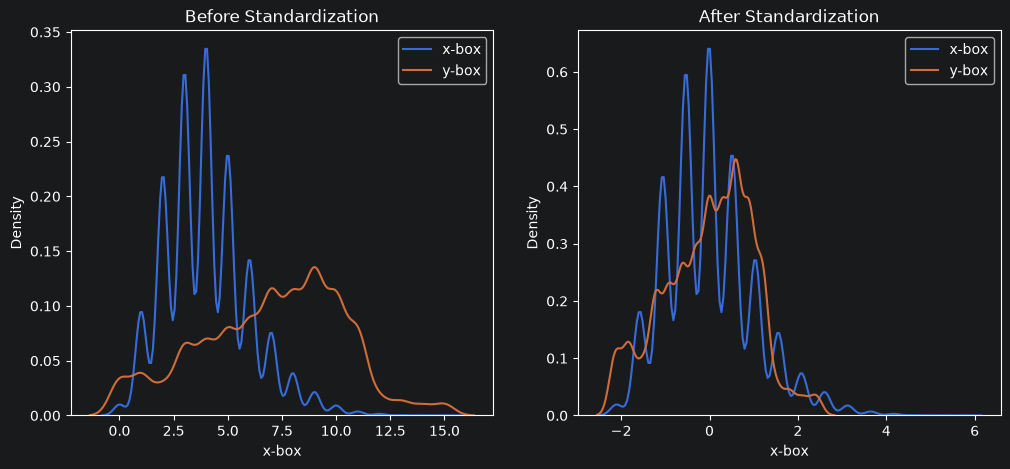

In [3]:
# 5. Visualizing the effect of Standardization (Before vs After)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Scaling
ax1.set_title('Before Standardization')
sns.kdeplot(df['x-box'], ax=ax1, label='x-box')
sns.kdeplot(df['y-box'], ax=ax1, label='y-box')
ax1.legend()

# After Scaling
ax2.set_title('After Standardization')
sns.kdeplot(df_scaled['x-box'], ax=ax2, label='x-box')
sns.kdeplot(df_scaled['y-box'], ax=ax2, label='y-box')
ax2.legend()

plt.show()